In [1]:
#行動・観測データの読み込み
import json
import csv
import pandas as pd
p_id=["p01","p02","p03","p04","p05","p06","p07","p08","p09","p10","p11","p12","p13","p14","p15","p16","p17","p18","p19","p20","p21","p22","p23","p24","p25","p26","p27","p28","p29","p30","p31","p32","p33","p34","p35","p36","p37","p38","p39","p40"]
blocknum=0
run_num=1
first_sa_small_count=[]
first_sa_large_count=[]
for p in p_id:
    first_sa_small_count_p=0
    first_sa_large_count_p=0

    # JSONファイルのパス
    file_path = f"/mnt/c/Users/takuma/presentation_bandit/log/bandit_{p}_0{run_num}.csv"
    #file_path = f"/mnt/c/Users/takuma/presentation_bandit/log/bandit_{p}_0{run_num}.csv"
    

    # 読み込み
    df = pd.read_csv(file_path)
    # データを確認
    sa1_list=df["arm_left_sa"].tolist()
    sa2_list=df["arm_right_sa"].tolist()
    sb1_list=df["arm_left_sb"].tolist()
    print(f"sa1=",sa1_list)
    print(f"sa2=",sa2_list)
    #print(sa)
    # slotのリスト
    slots = df["choice"].tolist()
    slots = [(3 if x == 0 else x) - 1 for x in slots]
    # rewardのリスト
    rewards = df["reward_int"].tolist()#1足す？
    Timerange=len(slots)
    u_data=slots
    print(u_data)
    print(int(len(slots)/4))
    o_data=rewards
    for i in range(int(len(slots)/4)):
        first_select_idx=u_data[i*4]
        if sa1_list[i*4]<sa2_list[i*4]:
            if first_select_idx==0:
                first_sa_small_count_p+=1
            elif first_select_idx==1:
                first_sa_large_count_p+=1
        elif sa1_list[i*4]>sa2_list[i*4]:
            if first_select_idx==0:
                first_sa_large_count_p+=1
            elif first_select_idx==1:
                first_sa_small_count_p+=1
    first_sa_small_count.append(first_sa_small_count_p)
    first_sa_large_count.append(first_sa_large_count_p)



sa1= [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0]
sa2= [0, 0, 0, 0, 12, 12, 12, 12, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 12, 12, 12, 12, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 12, 12, 

<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8810/902357080.py:85: SyntaxWarning: invalid escape sequence '\s'
  labels=[f"Small diagnisticity(1/\sigma_A) slot", "Large diagnisticity(1/\sigma_A) slot"],
/tmp/ipykernel_8810/902357080.py:85: SyntaxWarning: invalid escape sequence '\s'
  labels=[f"Small diagnisticity(1/\sigma_A) slot", "Large diagnisticity(1/\sigma_A) slot"],


SA small first: n=40, M=27.15, SD=9.64
SA large first: n=40, M=7.67, SD=8.92
Saved: None


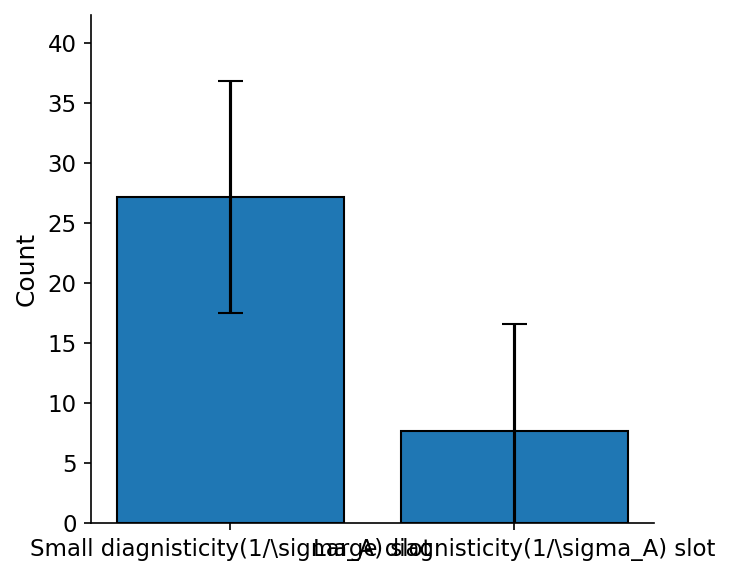

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
num_slot=2
#棒グラフ化
def summarize_stats(arr):
    """平均と標本標準偏差（ddof=1）を返す。要素が1個以下ならSDはnp.nan。"""
    a = np.asarray(arr, dtype=float)
    mean = np.nanmean(a)
    sd = np.nan if a.size < 2 else np.nanstd(a, ddof=1)
    return mean, sd

def print_stats(name, arr):
    m, s = summarize_stats(arr)
    n = len(arr)
    # APA風の表示: M = x.xx, SD = x.xx
    if np.isnan(s):
        print(f"{name}: n={n}, M={m:.2f}, SD=NA (要素数が1以下)")
    else:
        print(f"{name}: n={n}, M={m:.2f}, SD={s:.2f}")

def apa_barplot(data_list, labels, ylabel="Count", title="First Selection by SA (APA-style)", save_base="apa_barplot"):
    """
    data_list: list of 1D-arrays (各条件のデータ)
    labels: 各バーのラベル
    """
    # 統計量計算
    means = []
    sds = []
    ns = []
    for d in data_list:
        m, s = summarize_stats(d)
        means.append(m)
        sds.append(0 if np.isnan(s) else s)  # SDが計算不能なら0表示に
        ns.append(len(d))

    # --- 図の設定（APAライク：モノクロ、最小限） ---
    plt.rcParams.update({
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 150,
    })

    fig, ax = plt.subplots(figsize=(5, 4))  # 単独プロット、サブプロットなし

    x = np.arange(len(labels))

    # 色は指定しない（モノクロデフォルト）。エラーバー=標準偏差
    bars = ax.bar(x, means, yerr=sds, capsize=6, linewidth=1, edgecolor="black")  # 枠線だけ黒

    # 軸とスパイン調整（APA風）
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, labels)
    #ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # グリッドは非表示
    ax.grid(False)
    # y軸は0開始（カウントなので自然）
    ymin = 0
    ymax = max(means[i] + sds[i] for i in range(len(means)))
    ax.set_ylim(ymin, ymax * 1.15 if ymax > 0 else 1)

    # 各バーの上に n を表示（必要なら削除可）
    # for i, b in enumerate(bars):
    #     ax.text(b.get_x() + b.get_width() / 2, b.get_height() + (sds[i] if sds[i] > 0 else 0) + (0.02 * ymax if ymax > 0 else 0.05),
    #             f"n={ns[i]}", ha="center", va="bottom", fontsize=10)

    fig.tight_layout()



# ---- 使い方 ----
# 統計量出力
print_stats("SA small first", first_sa_small_count)
print_stats("SA large first", first_sa_large_count)

# 図の作成
paths = apa_barplot(
    data_list=[first_sa_small_count, first_sa_large_count],
    labels=[f"Small diagnisticity(1/\sigma_A) slot", "Large diagnisticity(1/\sigma_A) slot"],
    ylabel="Count",
    title="First Selection",
    save_base="apa_barplot"
)
print("Saved:", paths)
# # スロット番号（1〜4）をラベルとして使用
# slot_labels = [f'Slot {i+1}' for i in range(num_slot)]
# #slot_labels = ['Slot 1', 'Slot 2', 'Slot 3', 'Slot 4']
# # グラフを描画
# plt.figure(figsize=(8, 5))
# plt.bar(slot_labels, slot_counts, color='blue', edgecolor='black')
# # タイトルとラベルの設定
# plt.title('Slot Selection Frequency')
# plt.xlabel('Slots')
# plt.ylabel('Number of Selections')
# # グリッド線と表示
# plt.grid(axis='y', linestyle='', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [3]:
import numpy as np
from scipy import stats

# ============================
# Paired statistics and effect sizes
# ============================

# low sigma_A = high diagnosticity
x_low = np.asarray(first_sa_small_count, dtype=float)

# high sigma_A = low diagnosticity
x_high = np.asarray(first_sa_large_count, dtype=float)

# 対応ありなので，両方が NaN でない参加者のみ残す
mask = ~np.isnan(x_low) & ~np.isnan(x_high)
x_low = x_low[mask]
x_high = x_high[mask]

diff = x_low - x_high
n = len(diff)

def mean_sd_sem(x):
    x = np.asarray(x, dtype=float)
    return np.mean(x), np.std(x, ddof=1), stats.sem(x, nan_policy="omit")

def cohens_dz_paired(x, y):
    """
    対応あり Cohen's dz
    dz = mean(x - y) / SD(x - y)
    """
    d = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    return np.mean(d) / np.std(d, ddof=1)

def hedges_g_av_paired(x, y):
    """
    対応ありデータでよく使われる g_av
    g_av = mean difference / average SD
    小標本補正つき
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    sd_av = np.sqrt((np.std(x, ddof=1)**2 + np.std(y, ddof=1)**2) / 2)
    d_av = (np.mean(x) - np.mean(y)) / sd_av

    # Hedges correction
    df = len(x) - 1
    correction = 1 - 3 / (4 * df - 1)
    g_av = d_av * correction

    return g_av

# ----------------------------
# Descriptive statistics
# ----------------------------
m_low, sd_low, sem_low = mean_sd_sem(x_low)
m_high, sd_high, sem_high = mean_sd_sem(x_high)
m_diff, sd_diff, sem_diff = mean_sd_sem(diff)

print("Descriptive statistics")
print(f"High-diagnosticity slot: n={n}, M={m_low:.3f}, SD={sd_low:.3f}, SEM={sem_low:.3f}")
print(f"Low-diagnosticity slot : n={n}, M={m_high:.3f}, SD={sd_high:.3f}, SEM={sem_high:.3f}")
print(f"Difference             : Mdiff={m_diff:.3f}, SDdiff={sd_diff:.3f}, SEMdiff={sem_diff:.3f}")
print()

# ----------------------------
# Paired t-test
# H1: high-diagnosticity > low-diagnosticity
# ----------------------------
t_stat, p_two = stats.ttest_rel(x_low, x_high)

# 片側検定に変換
if t_stat >= 0:
    p_one = p_two / 2
else:
    p_one = 1 - p_two / 2

df = n - 1
dz = cohens_dz_paired(x_low, x_high)
g_av = hedges_g_av_paired(x_low, x_high)

print("Paired t-test")
print(f"t({df}) = {t_stat:.3f}, one-sided p = {p_one:.4f}, two-sided p = {p_two:.4f}")
print(f"Cohen's dz = {dz:.3f}")
print(f"Hedges' g_av = {g_av:.3f}")
print()

# ----------------------------
# Wilcoxon signed-rank test
# H1: high-diagnosticity > low-diagnosticity
# ----------------------------
d_nz = diff[diff != 0]
n_eff = len(d_nz)

w_stat, p_wil = stats.wilcoxon(
    x_low,
    x_high,
    alternative="greater",
    zero_method="wilcox",
    method="auto"
)

# z相当量：片側p値から逆算
# p が極端に 0 になる場合に備えて下限を設定
p_for_z = max(p_wil, np.finfo(float).tiny)
z_stat = stats.norm.isf(p_for_z)

# Wilcoxon effect size r = z / sqrt(n_nonzero)
r = z_stat / np.sqrt(n_eff)

# rank-biserial correlation
abs_ranks = stats.rankdata(np.abs(d_nz))
t_plus = np.sum(abs_ranks[d_nz > 0])
t_minus = np.sum(abs_ranks[d_nz < 0])
r_rb = (t_plus - t_minus) / (t_plus + t_minus)

print("Wilcoxon signed-rank test")
print(f"W = {w_stat:.3f}, z = {z_stat:.3f}, one-sided p = {p_wil:.4f}")
print(f"n_nonzero = {n_eff}")
print(f"Effect size r = {r:.3f}")
print(f"Rank-biserial correlation = {r_rb:.3f}")
print()

# ----------------------------
# 論文記載用の文字列を自動生成
# ----------------------------
print("Result sentence candidates")
print(
    f"Participants selected the high-diagnosticity slot more frequently "
    f"(M = {m_low:.2f}, SD = {sd_low:.2f}) than the low-diagnosticity slot "
    f"(M = {m_high:.2f}, SD = {sd_high:.2f}) on the first trial of each block, "
    f"t({df}) = {t_stat:.2f}, p = {p_one:.3f}, dz = {dz:.2f}."
)

print(
    f"A Wilcoxon signed-rank test yielded a similar result, "
    f"W = {w_stat:.2f}, z = {z_stat:.2f}, p = {p_wil:.3f}, "
    f"r = {r:.2f}, rank-biserial r = {r_rb:.2f}."
)

Descriptive statistics
High-diagnosticity slot: n=40, M=27.150, SD=9.638, SEM=1.524
Low-diagnosticity slot : n=40, M=7.675, SD=8.920, SEM=1.410
Difference             : Mdiff=19.475, SDdiff=18.463, SEMdiff=2.919

Paired t-test
t(39) = 6.671, one-sided p = 0.0000, two-sided p = 0.0000
Cohen's dz = 1.055
Hedges' g_av = 2.057

Wilcoxon signed-rank test
W = 735.000, z = 4.372, one-sided p = 0.0000
n_nonzero = 40
Effect size r = 0.691
Rank-biserial correlation = 0.793

Result sentence candidates
Participants selected the high-diagnosticity slot more frequently (M = 27.15, SD = 9.64) than the low-diagnosticity slot (M = 7.67, SD = 8.92) on the first trial of each block, t(39) = 6.67, p = 0.000, dz = 1.05.
A Wilcoxon signed-rank test yielded a similar result, W = 735.00, z = 4.37, p = 0.000, r = 0.69, rank-biserial r = 0.79.


findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


SA small first: n=40, M=27.15, SD=9.64, SEM=1.52
SA large first: n=40, M=7.67, SD=8.92, SEM=1.41
Wilcoxon signed-rank (one-sided, small>large): W=735.000, p=0.0000


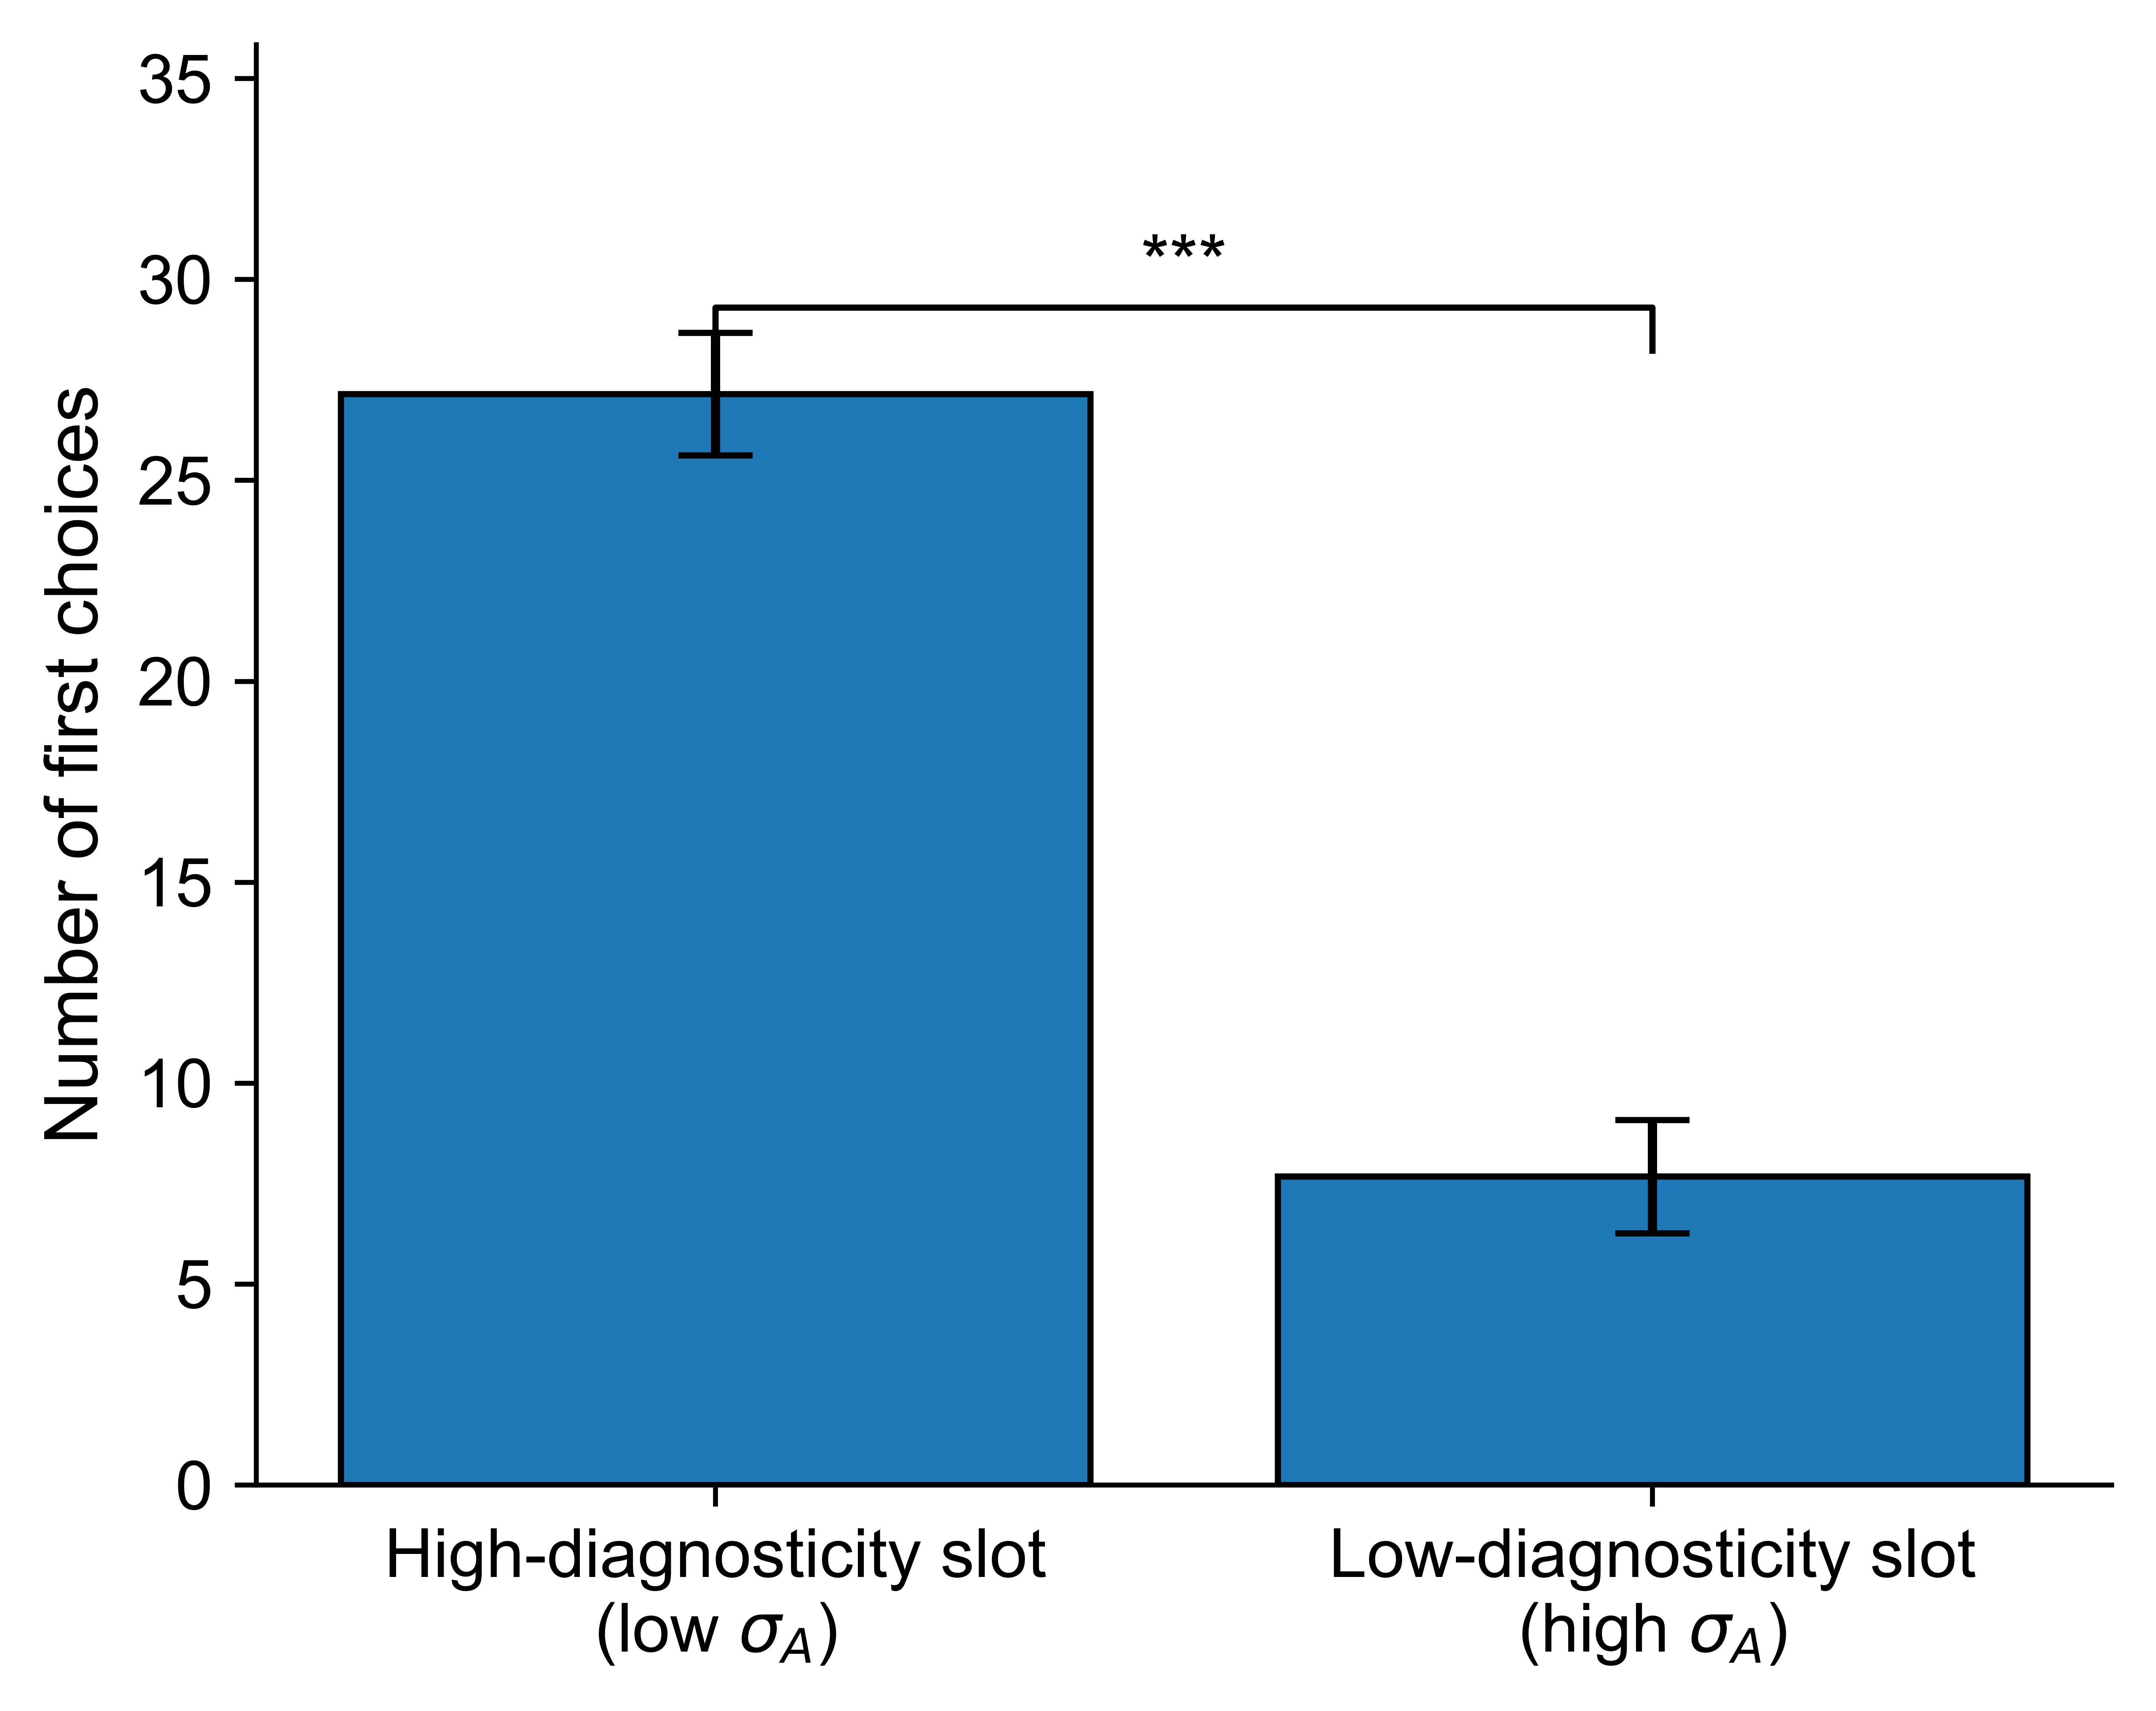

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats   # ★ 追加
%matplotlib inline

num_slot = 2

# ---- 統計量まわり ----
# ---- 統計量まわり ----
def summarize_stats(arr):
    """
    平均，標本標準偏差（SD），標準誤差（SEM）を返す。
    要素数が1以下ならSDとSEMはnp.nan。
    """
    a = np.asarray(arr, dtype=float)
    a = a[~np.isnan(a)]

    n = len(a)
    mean = np.nanmean(a)

    if n < 2:
        sd = np.nan
        sem = np.nan
    else:
        sd = np.nanstd(a, ddof=1)
        sem = sd / np.sqrt(n)

    return mean, sd, sem


def print_stats(name, arr):
    m, s, sem = summarize_stats(arr)
    n = len(np.asarray(arr)[~np.isnan(arr)])

    if np.isnan(s):
        print(f"{name}: n={n}, M={m:.2f}, SD=NA, SEM=NA")
    else:
        print(f"{name}: n={n}, M={m:.2f}, SD={s:.2f}, SEM={sem:.2f}")

# ---- APA 風バーグラフ ----
def apa_barplot(data_list, labels, ylabel="Count",
                title="First Selection by SA (APA-style)",
                save_base="apa_barplot"):
    """
    data_list: list of 1D-arrays (各条件のデータ, 要素数 n は被験者数)
    labels: 各バーのラベル
    """
    # 統計量計算
    means = []
    sems = []
    ns = []
    for d in data_list:
        m, sd, sem = summarize_stats(d)
        means.append(m)
        sems.append(0 if np.isnan(sem) else sem)
        ns.append(len(d))

    # --- 図の設定（APAライク：モノクロ、最小限） ---
    plt.rcParams.update({
        # Font
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "mathtext.fontset": "custom",
        "mathtext.rm": "Helvetica",
        "mathtext.it": "Helvetica:italic",
        "mathtext.bf": "Helvetica:bold",

        # Editable text in PDF/PS
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # Figure style
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 1200,
    })

    fig, ax = plt.subplots(figsize=(5, 4))  # 単独プロット、サブプロットなし

    x = np.arange(len(labels))

    # 色は指定しない（モノクロデフォルト）。エラーバー=標準偏差
    bars = ax.bar(
        x, means,
        yerr=sems,
        capsize=6,
        linewidth=1,
        edgecolor="black"  # 枠線だけ黒
    )

    # 軸とスパイン調整（APA風）
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, labels)
    # ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    ymin = 0
    ymax = max(means[i] + sems[i] for i in range(len(means)))
    ax.set_ylim(ymin, ymax * 1.25 if ymax > 0 else 1)  # 少し大きめにとる

    fig.tight_layout()

    # ★ fig, ax, bars を返す（あとで有意差マークを書くため）
    return fig, ax, bars


# ---- 実際の使い方 ----
# 統計量出力
print_stats("SA small first", first_sa_small_count)
print_stats("SA large first", first_sa_large_count)

# 図の作成
fig, ax, bars = apa_barplot(
    data_list=[first_sa_small_count, first_sa_large_count],
    labels=[
    r"High-diagnosticity slot" + "\n" + r"(low $\sigma_A$)",
    r"Low-diagnosticity slot" + "\n" + r"(high $\sigma_A$)"
],
    ylabel="Number of first choices",
    title="First Selection",
    save_base="apa_barplot"
)

# ============================
# ここから検定と有意差マーク
# ============================

# データを NumPy 配列にして NaN を除去（対応のあるデータと仮定）
x1 = np.asarray(first_sa_small_count, dtype=float)
x2 = np.asarray(first_sa_large_count, dtype=float)
mask = ~np.isnan(x1) & ~np.isnan(x2)
x1 = x1[mask]
x2 = x2[mask]

# ---- どの検定を使うか選ぶ ----
use_test = "wilcoxon"   # "ttest" か "wilcoxon" を選択

if use_test == "ttest":
    # 対応のある t 検定（両側）をまず行う
    t_stat, p_two = stats.ttest_rel(x1, x2)
    # 片側検定 (H1: small > large)
    if t_stat > 0:
        p = p_two / 2.0
    else:
        p = 1.0 - p_two / 2.0
    print(f"Paired t-test (one-sided, small>large): t={t_stat:.3f}, p={p:.4f}")

elif use_test == "wilcoxon":
    # Wilcoxon 符号付順位検定（片側, H1: small > large）
    # SciPy >=1.7 なら alternative='greater' が使えます
    w_stat, p = stats.wilcoxon(x1, x2, alternative='greater')
    print(f"Wilcoxon signed-rank (one-sided, small>large): W={w_stat:.3f}, p={p:.4f}")

else:
    raise ValueError("use_test は 'ttest' か 'wilcoxon' を指定してください。")

# ---- p 値から星の数を決める ----
if p < 0.001:
    star = '***'
elif p < 0.01:
    star = '**'
elif p < 0.05:
    star = '*'
else:
    star = 'n.s.'  # 有意でない場合も表示したければこれを使う。消したければ '' にしてもよい

# ---- 有意差マークをバー上に描く ----
# 2 本のバーを前提
bar1, bar2 = bars[0], bars[1]

x1_bar = bar1.get_x() + bar1.get_width() / 2.0
x2_bar = bar2.get_x() + bar2.get_width() / 2.0

y1_bar = bar1.get_height()
y2_bar = bar2.get_height()
y_max_bar = max(y1_bar, y2_bar)

# 線を描く高さ
y_offset = 0.03 * ax.get_ylim()[1]   # y 軸レンジに対するオフセット
line_y = y_max_bar + y_offset

# 線（┐ ┌みたいな形）
ax.plot([x1_bar, x1_bar, x2_bar, x2_bar],
        [line_y, line_y + y_offset, line_y + y_offset, line_y],
        color='black', linewidth=1)

# 星（または n.s.）を中央に
ax.text((x1_bar + x2_bar) / 2.0,
        line_y + y_offset * 1.1,
        star,
        ha='center', va='bottom', fontsize=12)

fig.tight_layout()
fig.savefig("first_choice_barplot.pdf", bbox_inches="tight")
fig.savefig("first_choice_barplot.svg", bbox_inches="tight")
fig.savefig("first_choice_barplot.png", dpi=600, bbox_inches="tight")
plt.show()


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

# ---- 統計量まわり ----
def summarize_stats(arr):
    """
    平均，標本標準偏差（SD），標準誤差（SEM）を返す。
    要素数が1以下ならSDとSEMはnp.nan。
    """
    a = np.asarray(arr, dtype=float)
    a = a[~np.isnan(a)]

    n = len(a)
    mean = np.nanmean(a)

    if n < 2:
        sd = np.nan
        sem = np.nan
    else:
        sd = np.nanstd(a, ddof=1)
        sem = sd / np.sqrt(n)

    return mean, sd, sem


def print_stats(name, arr):
    m, s, sem = summarize_stats(arr)
    n = len(np.asarray(arr)[~np.isnan(arr)])

    if np.isnan(s):
        print(f"{name}: n={n}, M={m:.2f}, SD=NA, SEM=NA")
    else:
        print(f"{name}: n={n}, M={m:.2f}, SD={s:.2f}, SEM={sem:.2f}")


# ---- APA風の共通設定 ----
def set_apa_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [ "Arial","Helvetica", "DejaVu Sans"],

        "mathtext.fontset": "custom",
        "mathtext.rm": "Helvetica",
        "mathtext.it": "Helvetica:italic",
        "mathtext.bf": "Helvetica:bold",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 1200,
    })


# ---- 箱ひげ図 ----
def apa_boxplot(data_list, labels, ylabel="Count",
                title="First Selection",
                show_points=True,
                show_pair_lines=True):
    """
    data_list: list of 1D-arrays
    labels: 各条件のラベル
    show_points: 各被験者の点を重ねるか
    show_pair_lines: 対応のあるデータとして個人内の線を引くか
    """
    set_apa_style()

    cleaned = []
    for d in data_list:
        a = np.asarray(d, dtype=float)
        cleaned.append(a)

    fig, ax = plt.subplots(figsize=(5, 4))

    positions = np.arange(1, len(labels) + 1)

    bp = ax.boxplot(
        cleaned,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1)
    )

    # 各被験者の点
    if show_points:
        rng = np.random.default_rng(123)

        for i, d in enumerate(cleaned):
            x_jitter = rng.normal(loc=positions[i], scale=0.04, size=len(d))
            ax.scatter(
                x_jitter,
                d,
                s=25,
                facecolors="white",
                edgecolors="black",
                linewidths=0.8,
                zorder=3
            )

    # 対応のあるデータとして線を引く
    if show_pair_lines and len(cleaned) == 2:
        x1 = cleaned[0]
        x2 = cleaned[1]
        mask = ~np.isnan(x1) & ~np.isnan(x2)

        for y1, y2 in zip(x1[mask], x2[mask]):
            ax.plot(
                [positions[0], positions[1]],
                [y1, y2],
                color="black",
                linewidth=0.5,
                alpha=0.35,
                zorder=1
            )

    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    # ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # y軸範囲
    all_values = np.concatenate([d[~np.isnan(d)] for d in cleaned])
    ymin = 0
    ymax = np.nanmax(all_values)
    ax.set_ylim(ymin, ymax * 1.25 if ymax > 0 else 1)

    fig.tight_layout()

    return fig, ax, positions


# ---- バイオリンプロット ----
def apa_violinplot(data_list, labels, ylabel="Count",
                   title="First Selection",
                   show_box=True,
                   show_points=True,
                   show_pair_lines=True):
    """
    data_list: list of 1D-arrays
    labels: 各条件のラベル
    show_box: バイオリンの上に箱ひげ図を重ねるか
    show_points: 各被験者の点を重ねるか
    show_pair_lines: 対応のあるデータとして個人内の線を引くか
    """
    set_apa_style()

    cleaned = []
    for d in data_list:
        a = np.asarray(d, dtype=float)
        cleaned.append(a)

    fig, ax = plt.subplots(figsize=(5, 4))

    positions = np.arange(1, len(labels) + 1)

    vp = ax.violinplot(
        [d[~np.isnan(d)] for d in cleaned],
        positions=positions,
        widths=0.7,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    # APA風に白塗り＋黒枠
    for body in vp["bodies"]:
        body.set_facecolor("white")
        body.set_edgecolor("black")
        body.set_linewidth(1)
        body.set_alpha(1)

    # 箱ひげ図を重ねる
    if show_box:
        ax.boxplot(
            cleaned,
            positions=positions,
            widths=0.25,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1.5),
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=1),
            whiskerprops=dict(color="black", linewidth=1),
            capprops=dict(color="black", linewidth=1)
        )

    # 各被験者の点
    if show_points:
        rng = np.random.default_rng(123)

        for i, d in enumerate(cleaned):
            x_jitter = rng.normal(loc=positions[i], scale=0.04, size=len(d))
            ax.scatter(
                x_jitter,
                d,
                s=25,
                facecolors="white",
                edgecolors="black",
                linewidths=0.8,
                zorder=3
            )

    # 対応のあるデータとして線を引く
    if show_pair_lines and len(cleaned) == 2:
        x1 = cleaned[0]
        x2 = cleaned[1]
        mask = ~np.isnan(x1) & ~np.isnan(x2)

        for y1, y2 in zip(x1[mask], x2[mask]):
            ax.plot(
                [positions[0], positions[1]],
                [y1, y2],
                color="black",
                linewidth=0.5,
                alpha=0.35,
                zorder=1
            )

    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    # ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # y軸範囲
    all_values = np.concatenate([d[~np.isnan(d)] for d in cleaned])
    ymin = 0
    ymax = np.nanmax(all_values)
    ax.set_ylim(ymin, ymax * 1.25 if ymax > 0 else 1)

    fig.tight_layout()

    return fig, ax, positions


# ---- 有意差マークを追加する関数 ----
def add_sig_mark(ax, positions, data_list, p, text=None):
    """
    positions: apa_boxplot / apa_violinplot が返す positions
    data_list: プロットしたデータ
    p: 検定のp値
    text: 任意の表示文字列。Noneならp値に応じて星を表示。
    """
    if text is None:
        if p < 0.001:
            text = "***"
        elif p < 0.01:
            text = "**"
        elif p < 0.05:
            text = "*"
        else:
            text = "n.s."

    x1_pos = positions[0]
    x2_pos = positions[1]

    all_values = np.concatenate([
        np.asarray(d, dtype=float)[~np.isnan(np.asarray(d, dtype=float))]
        for d in data_list
    ])

    y_max = np.nanmax(all_values)
    ylim_top = ax.get_ylim()[1]
    y_offset = 0.04 * ylim_top
    line_y = y_max + y_offset

    ax.plot(
        [x1_pos, x1_pos, x2_pos, x2_pos],
        [line_y, line_y + y_offset, line_y + y_offset, line_y],
        color="black",
        linewidth=1
    )

    ax.text(
        (x1_pos + x2_pos) / 2.0,
        line_y + y_offset * 1.1,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )

    # 有意差マークが切れないようにy軸を再調整
    ax.set_ylim(ax.get_ylim()[0], line_y + y_offset * 3.0)

SA small first: n=40, M=27.15, SD=9.64, SEM=1.52
SA large first: n=40, M=7.67, SD=8.92, SEM=1.41
Wilcoxon signed-rank (one-sided, small>large): W=735.000, p=0.0000


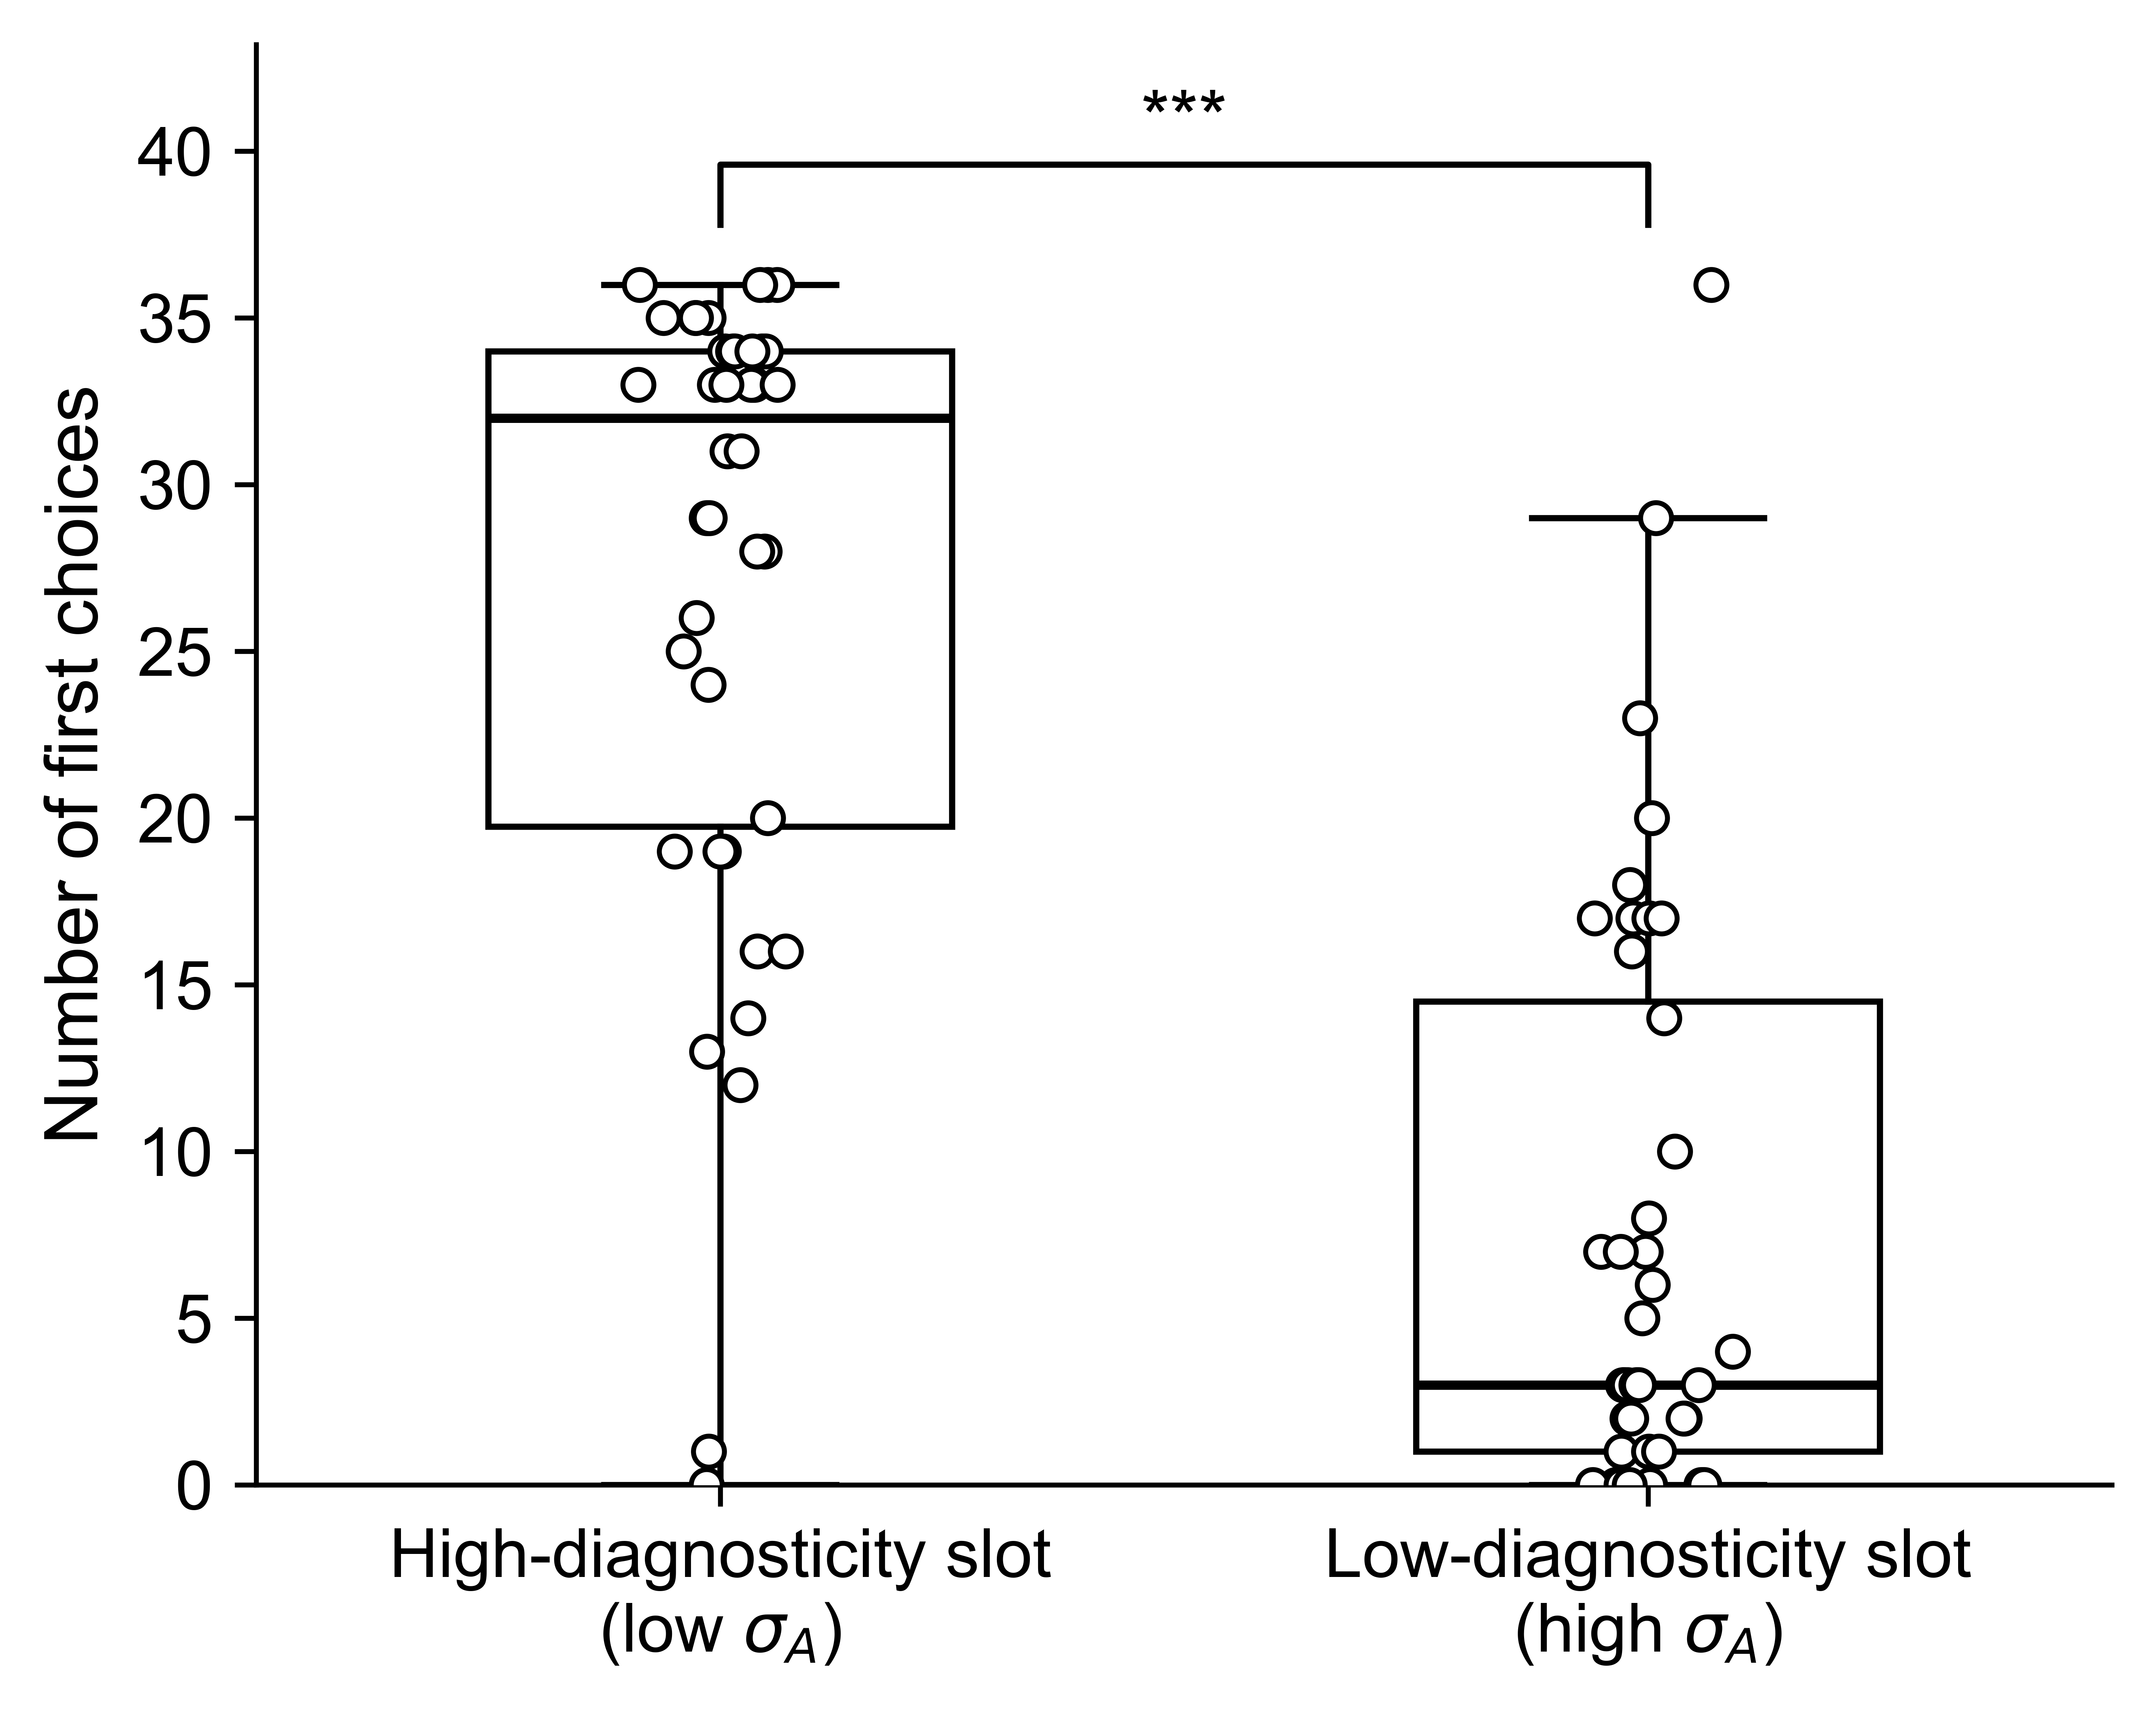

In [12]:
# ---- 実際の使い方 ----

# 統計量出力
print_stats("SA small first", first_sa_small_count)
print_stats("SA large first", first_sa_large_count)

data_list = [
    first_sa_small_count,
    first_sa_large_count
]

labels = [
    r"High-diagnosticity slot" + "\n" + r"(low $\sigma_A$)",
    r"Low-diagnosticity slot" + "\n" + r"(high $\sigma_A$)"
]

plot_type = "box"#"violin"  # "box" または "violin"

if plot_type == "box":
    fig, ax, positions = apa_boxplot(
        data_list=data_list,
        labels=labels,
        ylabel="Number of first choices",
        title="First Selection",
        show_points=True,
        show_pair_lines=False
    )

elif plot_type == "violin":
    fig, ax, positions = apa_violinplot(
        data_list=data_list,
        labels=labels,
        ylabel="Number of first choices",
        title="First Selection",
        show_box=True,
        show_points=True,
        show_pair_lines=False
    )

else:
    raise ValueError("plot_type は 'box' か 'violin' を指定してください。")


# ============================
# 検定
# ============================

x1 = np.asarray(first_sa_small_count, dtype=float)
x2 = np.asarray(first_sa_large_count, dtype=float)

# 対応のあるデータなので、両方がNaNでない被験者だけ使う
mask = ~np.isnan(x1) & ~np.isnan(x2)
x1 = x1[mask]
x2 = x2[mask]

use_test = "wilcoxon"   # "ttest" か "wilcoxon"

if use_test == "ttest":
    # 対応のある t 検定
    t_stat, p_two = stats.ttest_rel(x1, x2)

    # 片側検定 H1: small > large
    if t_stat > 0:
        p = p_two / 2.0
    else:
        p = 1.0 - p_two / 2.0

    print(f"Paired t-test (one-sided, small>large): t={t_stat:.3f}, p={p:.4f}")

elif use_test == "wilcoxon":
    # Wilcoxon符号付順位検定
    w_stat, p = stats.wilcoxon(x1, x2, alternative="greater")

    print(f"Wilcoxon signed-rank (one-sided, small>large): W={w_stat:.3f}, p={p:.4f}")

else:
    raise ValueError("use_test は 'ttest' か 'wilcoxon' を指定してください。")


# 有意差マーク
add_sig_mark(ax, positions, data_list, p)

fig.tight_layout()

# 保存
fig.savefig(f"first_choice_{plot_type}plot.pdf", bbox_inches="tight")
fig.savefig(f"first_choice_{plot_type}plot.svg", bbox_inches="tight")
fig.savefig(f"first_choice_{plot_type}plot.png", dpi=600, bbox_inches="tight")

plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histogram(data, title="Histogram", bins=10):
    data = np.asarray(data)
    data = data[~np.isnan(data)]  # NaN 除去

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=bins, edgecolor='black', alpha=0.7)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.grid(False)
    plt.show()


In [8]:
# ============================
# ここから検定と効果量（追加）
# ============================

# データを NumPy 配列にして NaN を除去（対応のあるデータと仮定）
x1 = np.asarray(first_sa_small_count, dtype=float)
x2 = np.asarray(first_sa_large_count, dtype=float)
mask = ~np.isnan(x1) & ~np.isnan(x2)
x1 = x1[mask]
x2 = x2[mask]

use_test = "wilcoxon"   # "ttest" か "wilcoxon"

def cohens_dz_paired(x1, x2):
    """対応ありの Cohen's dz = mean(diff)/sd(diff)"""
    d = x1 - x2
    sd = np.std(d, ddof=1)
    return np.nan if sd == 0 else (np.mean(d) / sd)

def wilcoxon_effects(x1, x2):
    """
    Wilcoxonの効果量を2種類返す:
    - r (Z/√n): 0.1/0.3/0.5 目安で small/medium/large
    - rank-biserial correlation (r_rb): [-1,1] の相関っぽい指標
    """
    d = x1 - x2
    # 0差はWilcoxonで除かれる（zero_methodに依存）。ここでは一般的に除外。
    d_nz = d[d != 0]
    n = len(d_nz)
    if n == 0:
        return np.nan, np.nan, n

    # SciPyのWは（設定によるが典型的には）正の差の順位和 T+ と同等の解釈でOK
    w_stat, p = stats.wilcoxon(x1, x2, alternative='greater')  # small>large

    # 正規近似のZ（連続性補正なしの簡易版）
    mu = n * (n + 1) / 4
    sigma = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
    z = (w_stat - mu) / sigma if sigma != 0 else np.nan
    r = z / np.sqrt(n) if n > 0 else np.nan

    # rank-biserial correlation: r_rb = (T+ - T-) / (n(n+1)/2)
    # ここで T- = 総順位和 - T+
    total_ranks = n * (n + 1) / 2
    t_plus = w_stat
    t_minus = total_ranks - t_plus
    r_rb = (t_plus - t_minus) / total_ranks

    return r, r_rb, n, w_stat, p, z

if use_test == "ttest":
    # 対応のある t 検定（両側）
    t_stat, p_two = stats.ttest_rel(x1, x2)

    # 片側検定 (H1: small > large)
    if t_stat > 0:
        p = p_two / 2.0
    else:
        p = 1.0 - p_two / 2.0

    dz = cohens_dz_paired(x1, x2)
    n = len(x1)

    print("Paired t-test (one-sided, H1: small > large)")
    print(f"  n={n}")
    print(f"  t={t_stat:.3f}, p={p:.4f}")
    print(f"  Effect size: Cohen's dz={dz:.3f}")

elif use_test == "wilcoxon":
    r, r_rb, n_nz, w_stat, p, z = wilcoxon_effects(x1, x2)

    print("Wilcoxon signed-rank (one-sided, H1: small > large)")
    print(f"  n(all pairs)={len(x1)}  /  n(nonzero diffs)={n_nz}")
    print(f"  W={w_stat:.3f}, p={p:.4f}")
    print(f"  Effect size: r=Z/sqrt(n)={r:.3f}  (Z={z:.3f})")
    print(f"  Effect size: rank-biserial r_rb={r_rb:.3f}")

else:
    raise ValueError("use_test は 'ttest' か 'wilcoxon' を指定してください。")

# ---- p 値から星 ----
if p < 0.001:
    star = '***'
elif p < 0.01:
    star = '**'
elif p < 0.05:
    star = '*'
else:
    star = 'n.s.'


Wilcoxon signed-rank (one-sided, H1: small > large)
  n(all pairs)=40  /  n(nonzero diffs)=40
  W=735.000, p=0.0000
  Effect size: r=Z/sqrt(n)=0.691  (Z=4.368)
  Effect size: rank-biserial r_rb=0.793


In [13]:
import numpy as np
import pandas as pd

# ============================
# 各参加者のデータを表にする
# ============================

high = np.asarray(first_sa_small_count, dtype=float)
low = np.asarray(first_sa_large_count, dtype=float)

# 対応のあるデータなので、どちらかが NaN の参加者は除外
mask = ~np.isnan(high) & ~np.isnan(low)

high_valid = high[mask]
low_valid = low[mask]

# 元の配列上での参加者番号
# 1始まりにしています
participant_id = np.arange(1, len(high) + 1)[mask]

diff = high_valid - low_valid

df = pd.DataFrame({
    "participant": participant_id,
    "high_diagnosticity": high_valid,
    "low_diagnosticity": low_valid,
    "difference_high_minus_low": diff
})

df

,participant,high_diagnosticity,low_diagnosticity,difference_high_minus_low
0,1,25.0,10.0,15.0
1,2,29.0,7.0,22.0
2,3,36.0,0.0,36.0
3,4,31.0,5.0,26.0
4,5,33.0,3.0,30.0
5,6,31.0,3.0,28.0
6,7,26.0,7.0,19.0
7,8,12.0,17.0,-5.0
8,9,24.0,4.0,20.0
9,10,35.0,1.0,34.0


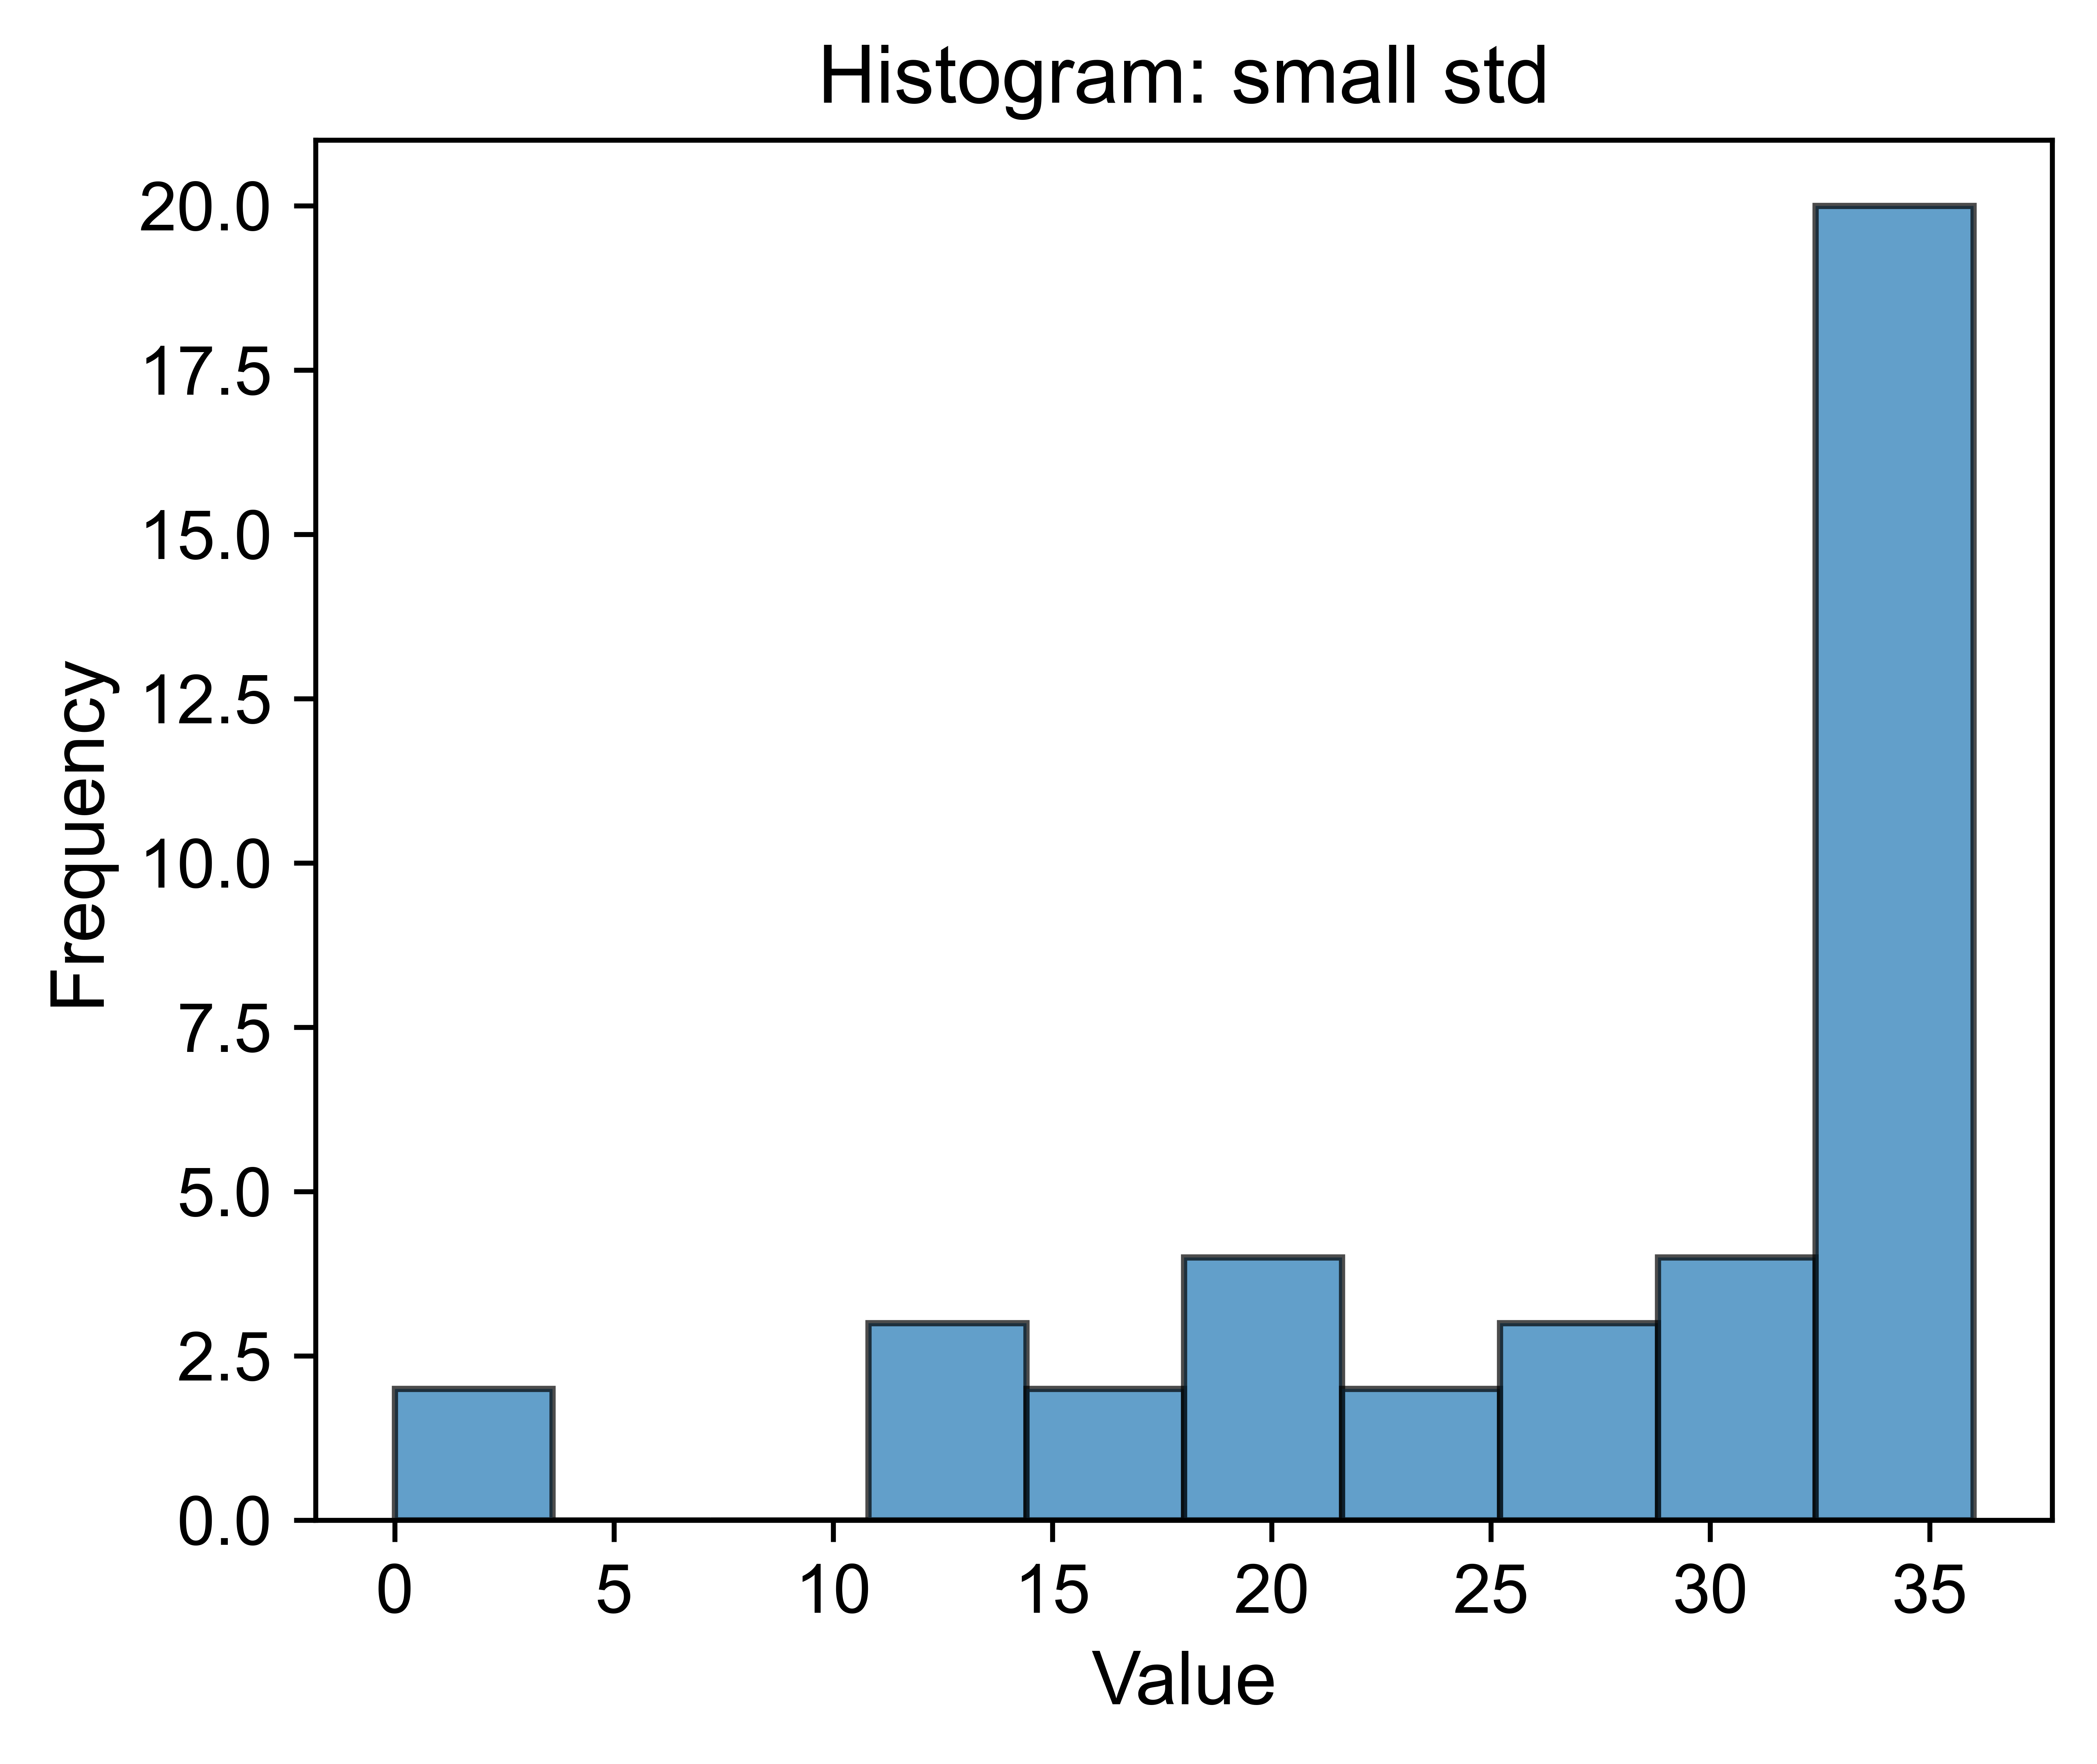

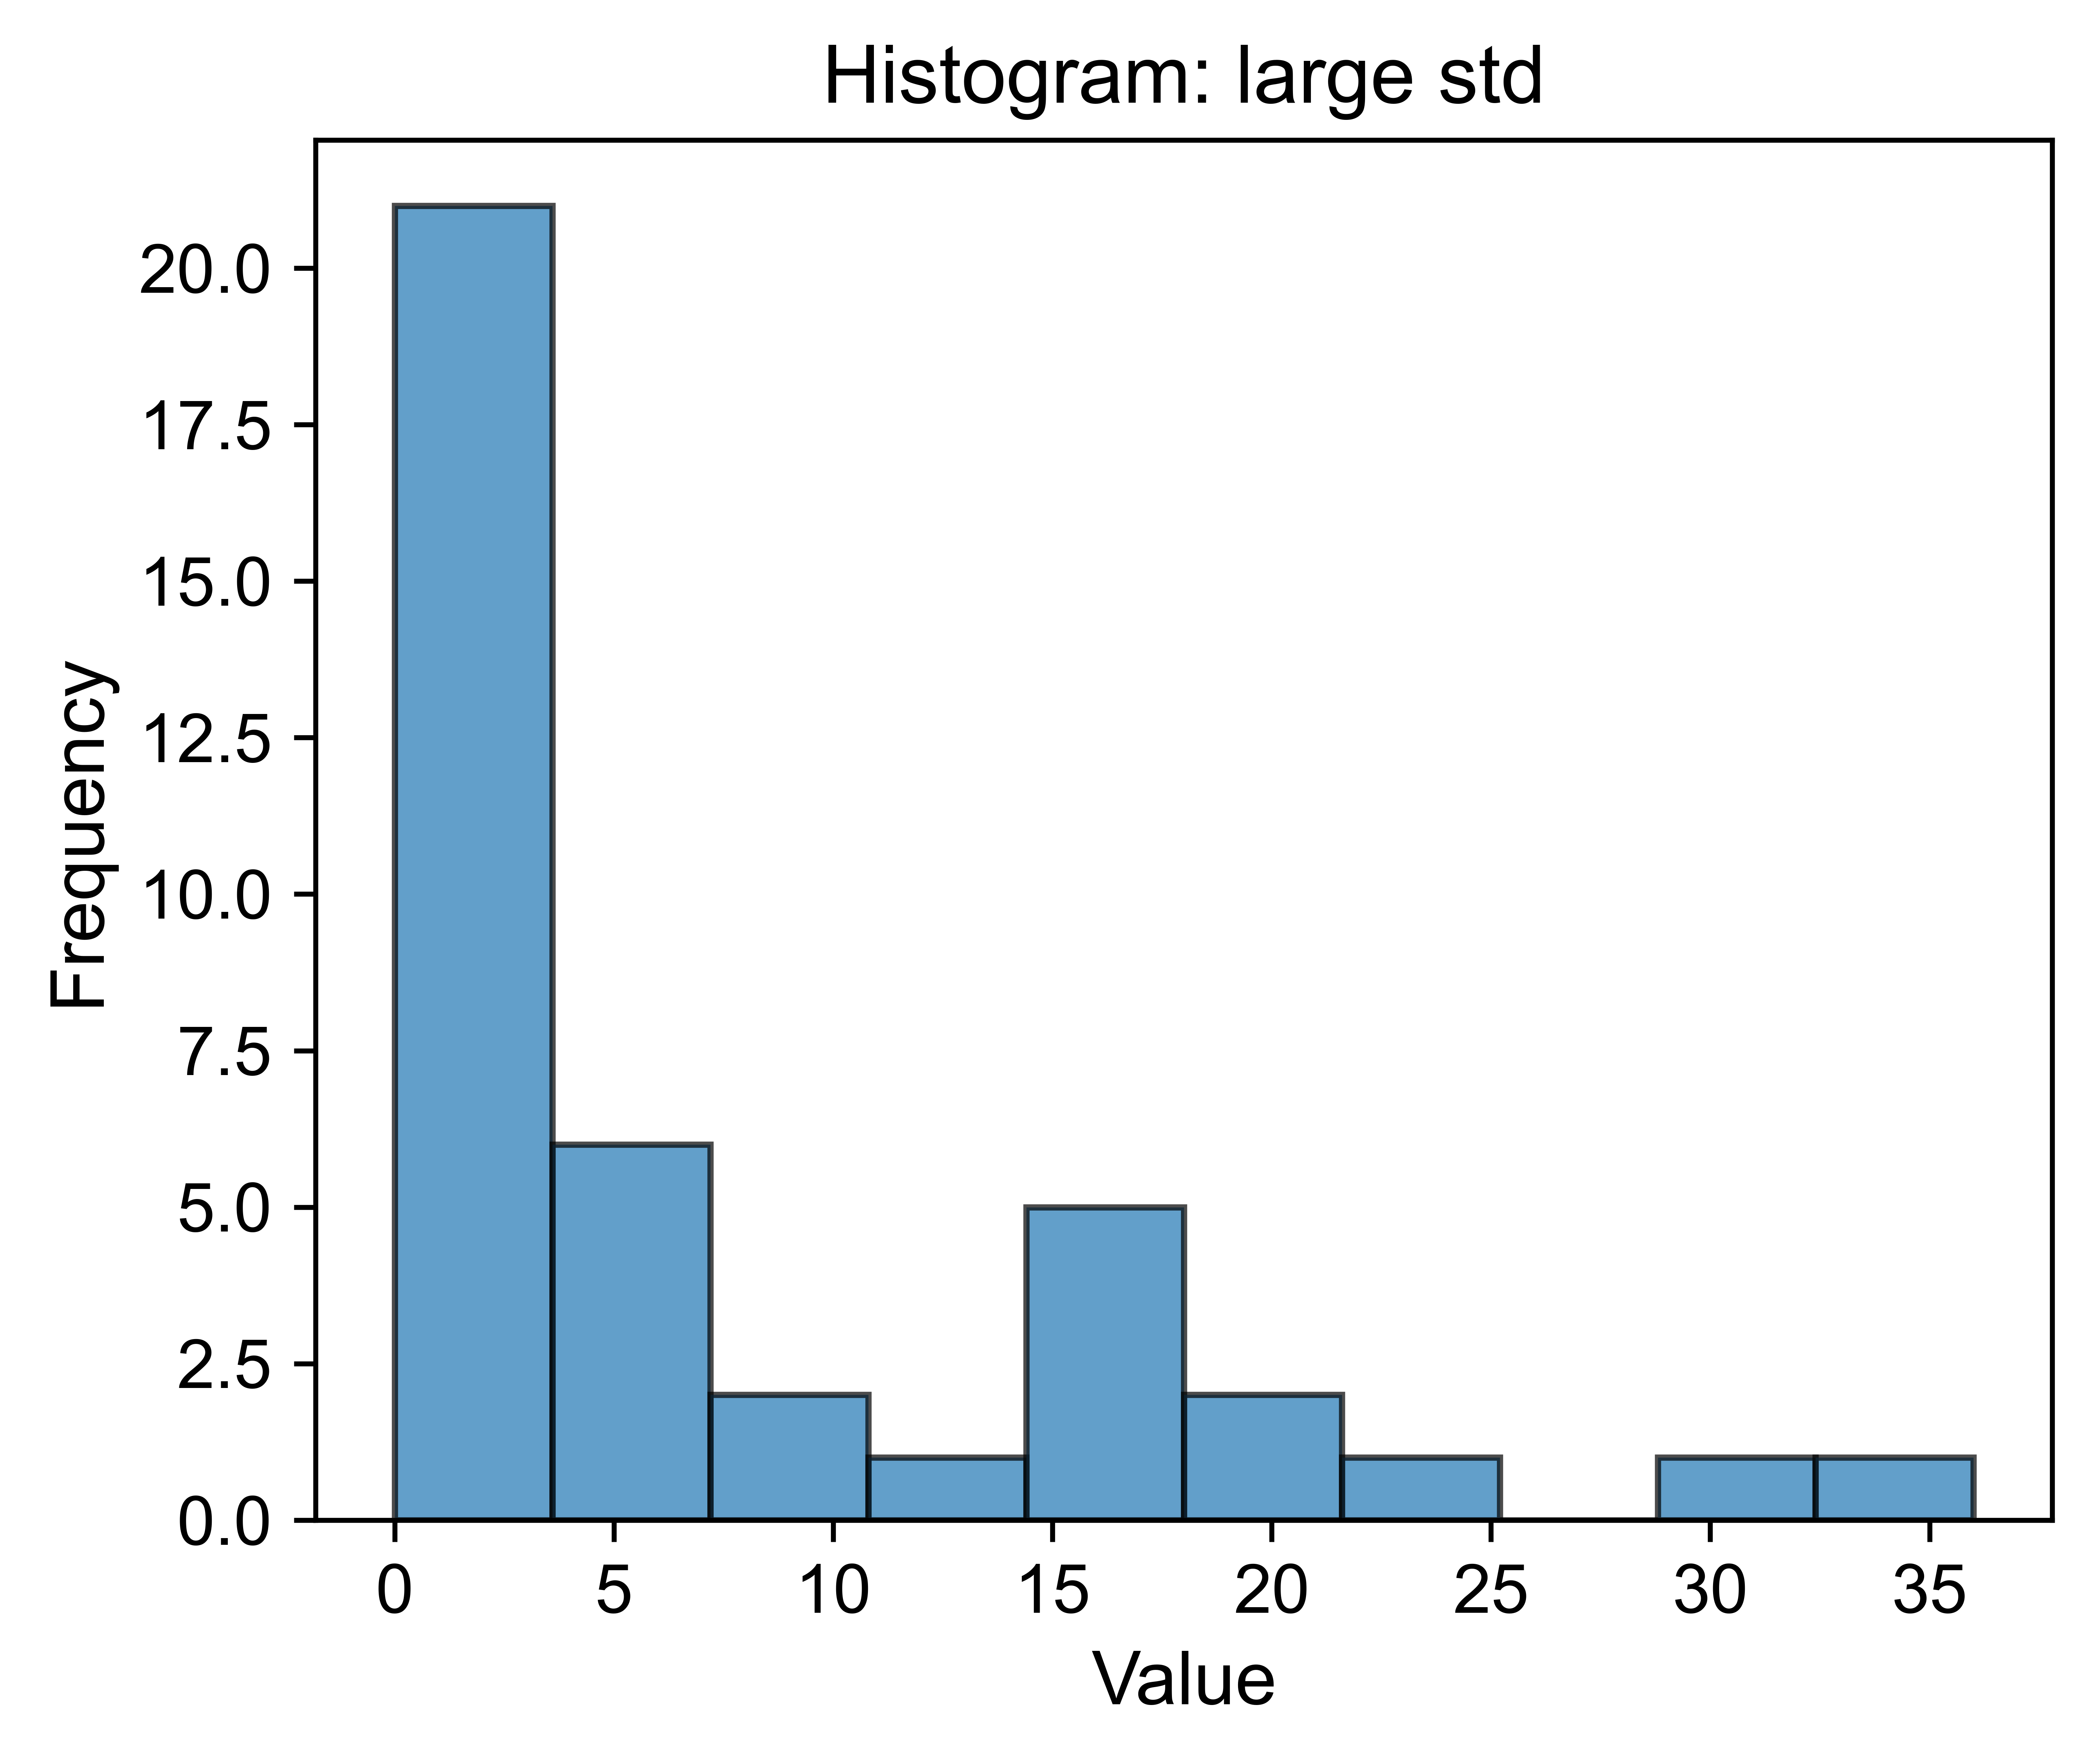

In [9]:
plot_histogram(first_sa_small_count, title="Histogram: small std")
plot_histogram(first_sa_large_count, title="Histogram: large std")
